## Provenance graph creation with voprov using add_one_step() function

#### Introduction

This notebook gives the sequence of commands to create a provenance graph for the processing of images taken at a telescope, for which we applied a bias and dark subtraction, then a flat-fielding to finally stack the images.

#### Installation

Python package:
https://github.com/sanguillon/voprov/

Based on the prov Python package:
https://github.com/trungdong/prov

```bash
pip install voprov
```

*Important*: the option "use_labels=True" of prov_to_dot() may not work if the ProvDocument contains Bundles

---

In [1]:
from voprov.model import VOProvDocument, VOProvBundle, VOPROV, PROV
from voprov.dot import prov_to_dot
from IPython.display import Image

In [2]:
pdoc = VOProvDocument()
pdoc.set_default_namespace(VOPROV.uri)
# add namespaces
pdoc.add_namespace('obs', 'http://myobservatory.com/instrument#');
pdoc.add_namespace('staff', 'http://myobservatory.com/staff#');
pdoc.add_namespace('ps', 'http://myobservatory.com/processes/');

Run a new ImageCalibration process with id=7531

In [3]:
process_id = 7531

In [4]:
onestep_1 = {
    "product_id": "obs:image1b",
    "product_role": "bias-subtracted-image",
    "contact_id": "mservillat",
    "step_id": "ps:2459",
    "step_name": "ps:bias_subtraction",
    "step_parameters": {"threshold": 10, "skip_null": True},
    "step_description": "remove the readout noise of the detector from the input image by subtracting a bias image",
    "step_software": ["gammapy_v1.2"],
    "used_ids": ["obs:image1", "obs:bias"],
    "generated_ids": [],
    "process_id": "7531",
    "workflow_name": "ImageCalibration",
    "instrument_id": "CTAO",
}

In [5]:
pdoc.add_one_step(onestep_1)

<VOProvDataSetEntity: obs:image1b>

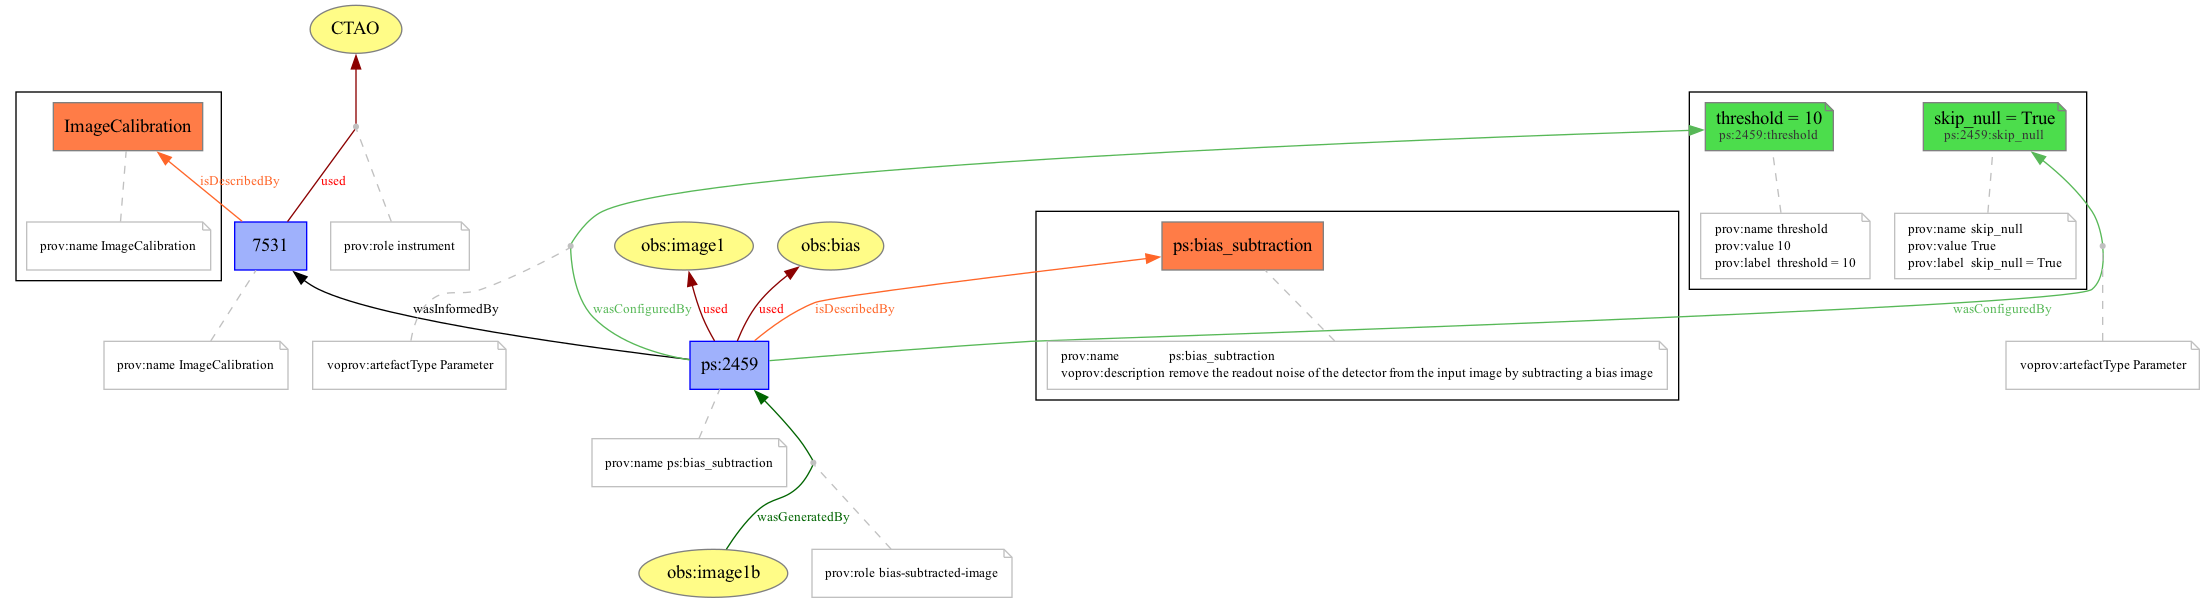

In [6]:
# Show graph
dot = prov_to_dot(pdoc, use_labels=True)
dot.write_png('voprov_example.png')
Image('voprov_example.png')

Define 3 images taken by an instrument as input entities:

In [7]:
print(pdoc.serialize(format="yaml"))

In [8]:
onestep_2 = {
    "product_id": "obs:image1bd",
    "product_name": None,
    "product_location": None,
    "product_generatedAtTime": None,
    "product_comment": None,
    "product_description": None,
    "product_type": None,
    "product_content_type": None,
    "product_docurl": None,
    "product_role": "dark-subtracted-image",
    "contact_id": None,
    "contact_name": None,
    "contact_type": None,
    "contact_email": None,
    "step_id": "ps:3094",
    "step_name": "ps:dark_subtraction",
    "step_startTime": None,
    "step_endTime": None,
    "step_comment": None,
    "step_parameters": {},
    "step_description": "remove the electronic noise of the detector from the input image by subtracting a dark image",
    "step_type": None,
    "step_docurl": None,
    "step_software": {},
    "used_ids": ["obs:image1b", "obs:dark"],
    "generated_ids": [],
    "process_id": "7531",
    "process_comment": None,
    "workflow_name": "ImageCalibration",
    "workflow_version": None,
    "workflow_description": None,
    "workflow_type": None,
    "workflow_docurl": None,
    "instrument_id": None,
    "instrument_location": None,
    "instrument_name": None,
    "instrument_description": None,
    "instrument_type": None,
    "instrument_docurl": None,
    "instrument_comment": None,
}
pdoc.add_one_step(onestep_2)

<VOProvDataSetEntity: obs:image1bd>

In [9]:
onestep_3 = {
    "product_id": "obs:image1bdf",
    "product_name": None,
    "product_location": None,
    "product_generatedAtTime": None,
    "product_comment": None,
    "product_description": None,
    "product_type": None,
    "product_content_type": None,
    "product_docurl": None,
    "product_role": "flat-fielded-image",
    "contact_id": None,
    "contact_name": None,
    "contact_type": None,
    "contact_email": None,
    "step_id": "ps:4034",
    "step_name": "ps:flat_application",
    "step_startTime": None,
    "step_endTime": None,
    "step_comment": None,
    "step_parameters": {},
    "step_description": "Applies flat-field correction to the input image",
    "step_type": None,
    "step_docurl": None,
    "step_software": {},
    "used_ids": ["obs:image1bd", "obs:flat"],
    "generated_ids": [],
    "process_id": "7531",
    "process_comment": None,
    "workflow_name": "ImageCalibration",
    "workflow_version": None,
    "workflow_description": None,
    "workflow_type": None,
    "workflow_docurl": None,
    "instrument_id": None,
    "instrument_location": None,
    "instrument_name": None,
    "instrument_description": None,
    "instrument_type": None,
    "instrument_docurl": None,
    "instrument_comment": None,
}
pdoc.add_one_step(onestep_3)

<VOProvDataSetEntity: obs:image1bdf>

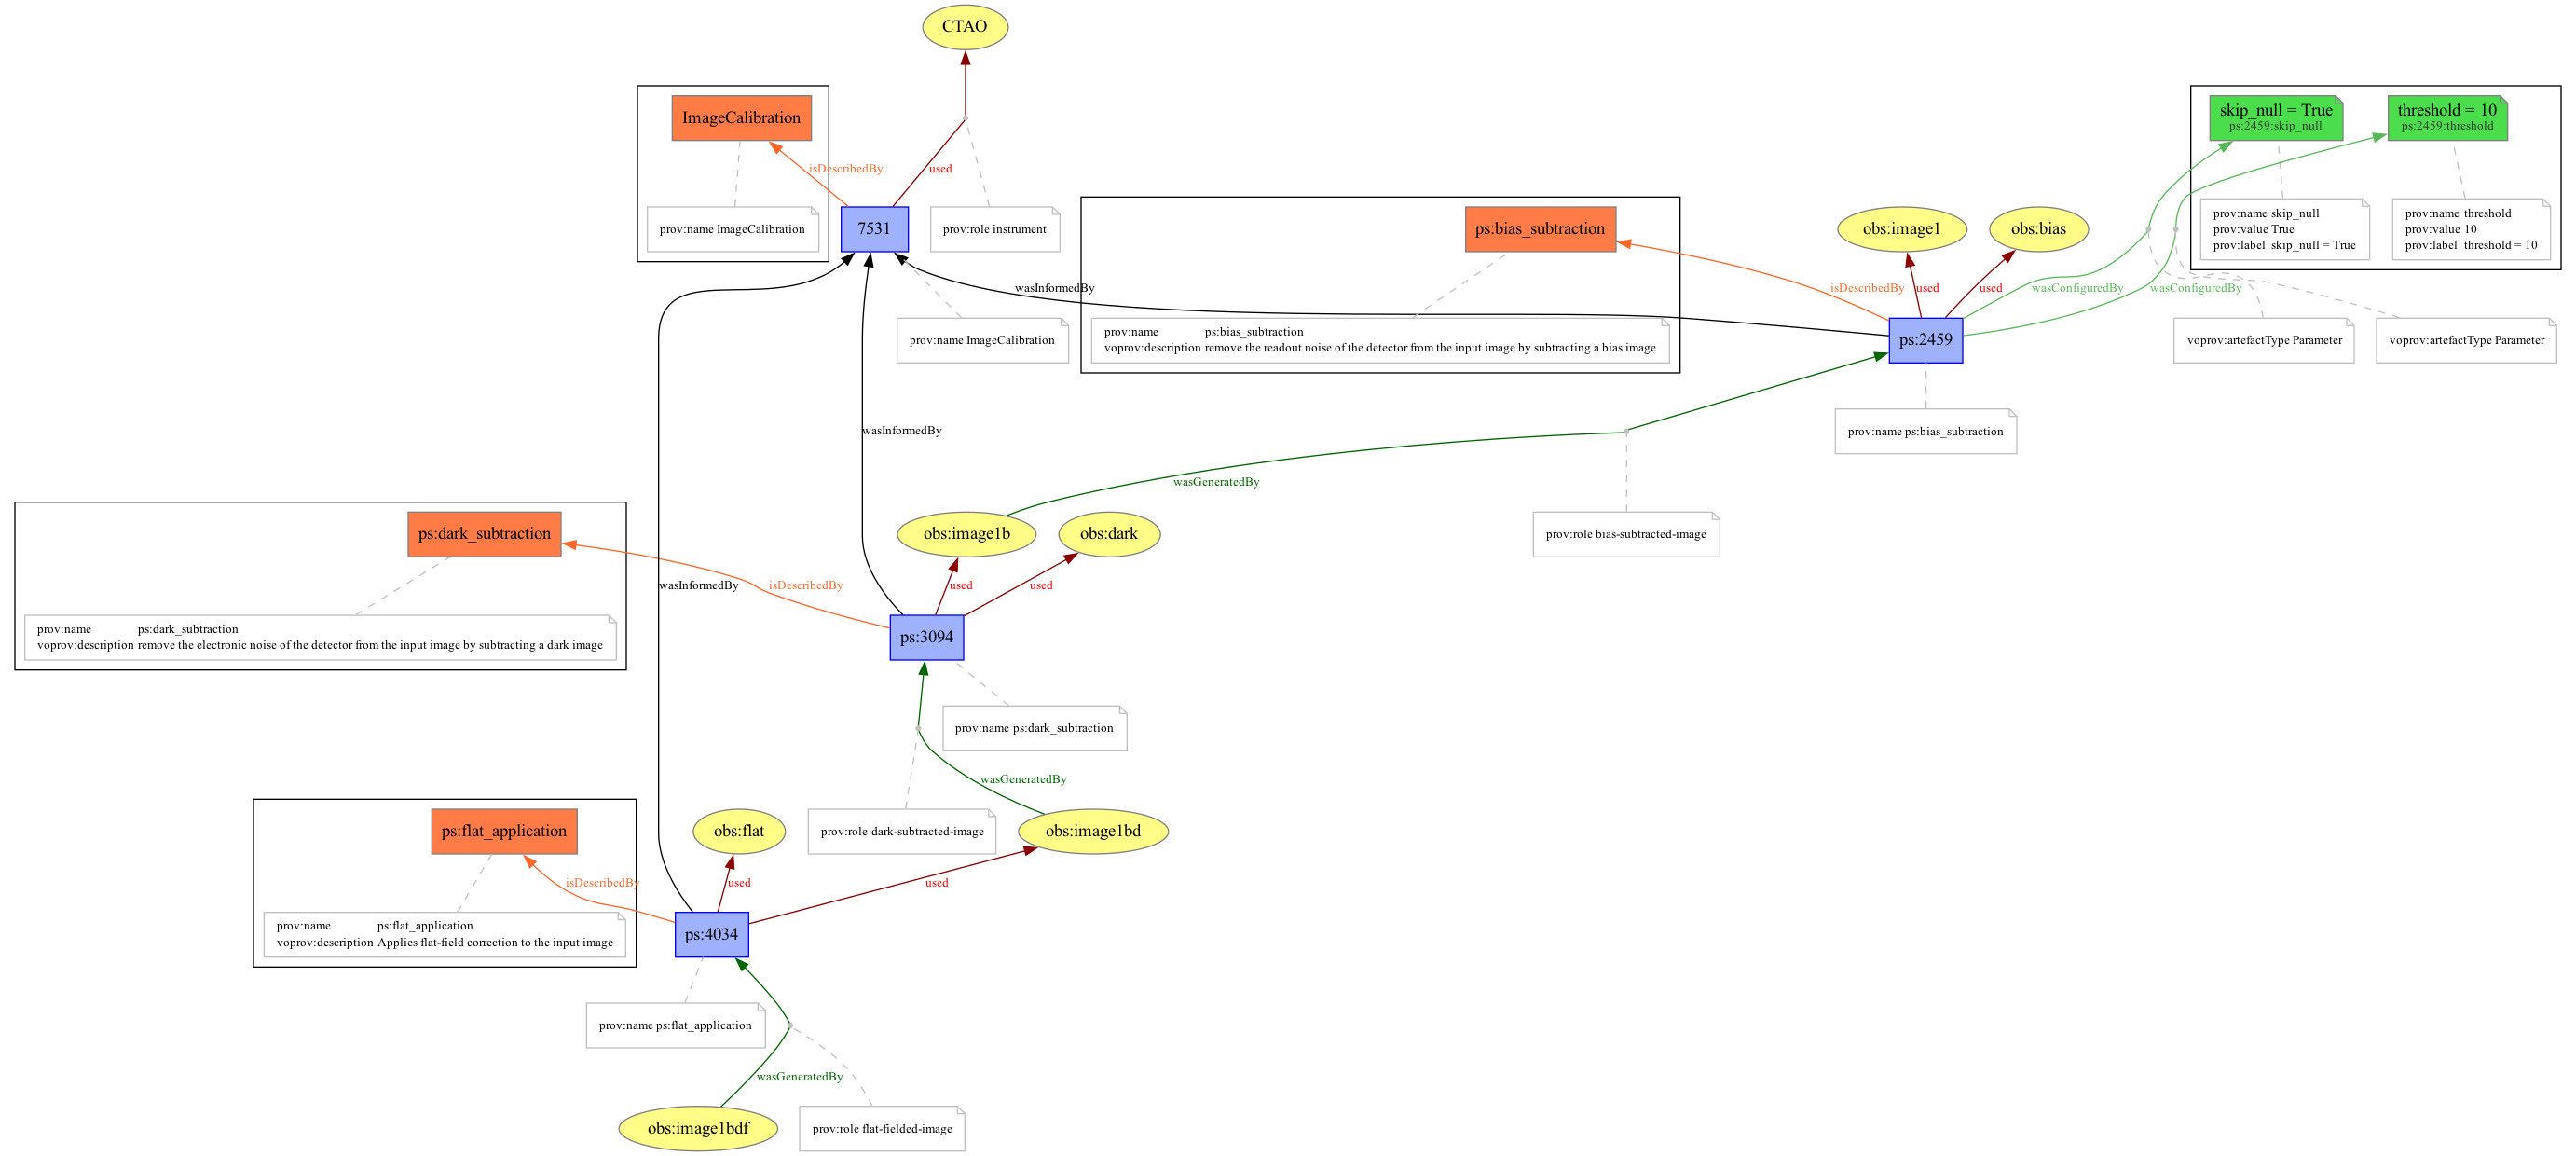

In [10]:
# Show graph
dot = prov_to_dot(pdoc, use_labels=True)
dot.write_png('voprov_example.png')
Image('voprov_example.png')

In [11]:
im1 = pdoc.entity('obs:image1', other_attributes={'prov:location': "/MyData/image1.fits"});
#im2 = pdoc.entity('obs:image2', other_attributes={'prov:location': "/MyData/image2.fits"});
#im3 = pdoc.entity('obs:image3', other_attributes={'prov:location': "/MyData/image3.fits"});

Define calibration files as additional input entities:

In [ ]:
bias = pdoc.entity('obs:bias', other_attributes={'prov:location': "/MyData/bias.fits"});
dark = pdoc.entity('obs:dark', other_attributes={'prov:location': "/MyData/dark.fits"});
flat = pdoc.entity('obs:flat', other_attributes={'prov:location': "/MyData/falt.fits"});

Define agents:

In [ ]:
im1.add_agent('staff:Emma', email="emma@myobservatory.com");
#im2.add_agent('staff:Emma', email="emma@myobservatory.com");
#im3.add_agent('staff:Emma', email="emma@myobservatory.com");
bias.add_agent('staff:Charles', email="georges@myobservatory.com");
dark.add_agent('staff:Charles', email="georges@myobservatory.com");
flat.add_agent('staff:Charles', email="georges@myobservatory.com");

In [ ]:
# Show graph
dot = prov_to_dot(pdoc, use_labels=True)
dot.write_png('voprov_example.png')
Image('voprov_example.png')